In [1]:
import scanpy as sc

In [2]:
adata = sc.read_h5ad("/data7/mark/STG/dataset/snRNA/merge_SCH_new/CSRES_4v3_500_1000gene/TH_downsampled_ratio.h5ad")

In [3]:
adata.obs["celltype.L2"].value_counts()

celltype.L2
MOL-1                      5940
Astrocyte-1                5265
MOL-2                      4803
TH Tll1_Thsd7b Glut        4514
TH Tnc_Cdh20 Glut          4078
TH Fam20a_Fbln1 Glut       3013
TH Car4_Tspan11 Glut       2914
TH Cald1_Gm39185 Glut      2480
TH Kcnk13_Nox4 Glut        2145
TH Meis2_Gm2115 GABA       1879
OPC                        1787
TH Ccdc192_Gli3 Glut       1304
TH Fgf10_Gm16263 Glut      1257
TH Egflam_Fbn2 Glut        1110
TH Col27a1_Npsr1 Glut       761
TH Parm1_Mdga1 Glut         670
MFOL                        492
TH Tac2_Pde11a Glut         426
Astrocyte-4                 336
Astrocyte-3                 302
MOL-3                       284
Microglia-1                 276
COP                         230
Ependymal cell              103
VLMC                         86
Endothelial cell             71
Microglia-2                  71
Choroid plexus cell          66
NFOL                         52
Perivascular Macrophage      29
Tanycyte                    

In [4]:
adata_subset = adata[adata.obs["celltype.L2"].isin(["TH Tll1_Thsd7b Glut"])]

In [5]:
# 探索 subset 数据结构
print(f"adata_subset shape: {adata_subset.shape}")
print(f"Obs columns: {list(adata_subset.obs.columns)}")
print(f"X type: {type(adata_subset.X)}")
print(f"X min/max: {adata_subset.X.min():.4f} / {adata_subset.X.max():.4f}")
print(f"细胞数量: {adata_subset.n_obs}")
print(f"基因数量: {adata_subset.n_vars}")
print()
# 查看分组信息
print("celltype.L2 value counts:")
print(adata_subset.obs["celltype.L2"].value_counts())
print()
# 查看是否有 batch 信息
for col in adata_subset.obs.columns:
    if "batch" in col.lower():
        print(f"Batch column: {col}")
        print(adata_subset.obs[col].value_counts())

adata_subset shape: (4514, 16428)
Obs columns: ['sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'scrublet_score', 'predicted_doublets', 'scrublet_leiden', 'cluster_scrublet_score', 'doublet_pval', 'doublet_bh_pval', 'date', 'status', 'sex', 'donor', 'region', 'company', 'cells_number', 'fraction_reads', 'mean_reads', 'median_umi', 'median_genes', 'total_genes', 'mapped_genome', 'mapped_confidently_genome', 'mapped_intergenic', 'mapped_intronic', 'mapped_exonic', 'mapped_transcriptome', 'antisense_gene', 'reads_number', 'valid_barcodes', 'sequencing_saturation', 'q30_barcode', 'q30_rna', 'q30_umi', 'tech', 'batch', 'predicted_labels'

In [6]:
# 查看可用于分组的列
for col in ["status", "region", "sex", "donor", "date"]:
    if col in adata_subset.obs.columns:
        print(f"\n{col} value counts:")
        print(adata_subset.obs[col].value_counts().head(20))


status value counts:
status
CON     2681
CSDS    1833
Name: count, dtype: int64

region value counts:
region
TH    4514
Name: count, dtype: int64

sex value counts:
sex
M    4514
Name: count, dtype: int64

donor value counts:
donor
MW22B    848
CS1-1    750
MW47A    633
MW51A    619
CS2-1    582
MW45A    581
CS7-3    501
Name: count, dtype: int64

date value counts:
date
20250411    1833
20250102    1200
20241024     848
20250107     633
Name: count, dtype: int64


In [7]:
# 检查 adata 是否有 raw 或 layers
print("Has raw:", adata.raw is not None)
if hasattr(adata, 'layers'):
    print("Layers keys:", list(adata.layers.keys()))
print("adata_subset.X shape:", adata_subset.X.shape)
print("adata_subset.X type:", type(adata_subset.X))

# 检查 var 是否有基因名
print("\nvar columns:", list(adata_subset.var.columns[:20]))
print("var index head:", adata_subset.var.index[:5].tolist())

Has raw: False
Layers keys: ['counts', None]
adata_subset.X shape: (4514, 16428)
adata_subset.X type: <class 'anndata._core.views.SparseCSRMatrixView'>

var columns: ['gene_ids']
var index head: ['Xkr4', 'Gm1992', 'Gm19938', 'Rp1', 'Mrpl15']


In [8]:
import sys
sys.path.insert(0, "/home/junyichen/code/RUVAEDEG")
from model import RUVVAE_DEG, compute_deg

import torch
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# 设置
batch_key = "batch"
group_key = "status"
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

In [9]:
hkg_priority = [
    "Aars", "Sars",
    "Polr2a", "Polr2f",
    "Psmd6", "Psmd7", "Psma5",
    "Rer1", "Ipo8", "Pop4", "Pes1",
    "Oaz1",
    "Rpl13a", "Rpl27", "Rps13", "Rps20",
    "Hprt1", "Gusb", "Ppia", "Ywhaz"
]

candidate_negative_control_genes = [
    # 在大规模跨组织分析中相对稳定
    "Oaz1",
    "Rps13",
    "Rps20",
    "Rpl27",

    # 小鼠脑中报告相对稳定的基础基因
    "Aars",
    "Polr2f",
    "Psmd6",
    "Psmd7",
    "Psma5",

    # RNA加工、核质运输与基础细胞维护
    "Ipo8",
    "Pop4",
    "Pes1",
    "Rer1",

    # 可作为补充候选，但必须在本数据中验证
    "Rpl13a",
    "Cyc1",
    "Sdha",
    "Ubc"
]

hkg_priority = candidate_negative_control_genes 

In [10]:
# ========== 1. 准备数据（全部基因） ==========
adata_hvg = adata_subset.copy()

# 清理数据中的 inf/nan
X_data = adata_hvg.X.toarray() if hasattr(adata_hvg.X, 'toarray') else adata_hvg.X.copy()
X_data = np.nan_to_num(X_data, nan=0.0, posinf=0.0, neginf=0.0)
adata_hvg.X = X_data

# Normalizing to median total counts
sc.pp.normalize_total(adata_hvg)
# Logarithmize the data
sc.pp.log1p(adata_hvg)

# 使用全部基因（不做 HVG 筛选）
n_genes_total = adata_hvg.n_vars
Y_all = X_data  # (n_cells, n_genes)
gene_names = adata_hvg.var.index.tolist()
print(f"基因总数: {n_genes_total}")
print(f"表达矩阵形状: {Y_all.shape}")
print(f"表达矩阵范围: {Y_all.min():.4f} ~ {Y_all.max():.4f}")

# 分组标签
group_labels = adata_hvg.obs[group_key].values
groups_unique = sorted(np.unique(group_labels).tolist())
print(f"分组: {groups_unique}")
print(f"CON: {(group_labels==groups_unique[0]).sum()}, CSDS: {(group_labels==groups_unique[1]).sum()}")

# 批次标签
batch_labels = adata_hvg.obs[batch_key].values
batches_unique = sorted(np.unique(batch_labels).tolist())
print(f"批次数量: {len(batches_unique)}")
print(f"批次: {batches_unique}")

基因总数: 16428
表达矩阵形状: (4514, 16428)
表达矩阵范围: 0.0000 ~ 7.3361
分组: ['CON', 'CSDS']
CON: 2681, CSDS: 1833
批次数量: 7
批次: ['CS1-1_TH_beirui', 'CS2-1_TH_beirui', 'CS7-3_TH_beirui', 'MW22B_TH_yunzhun', 'MW45A_TH_beirui', 'MW47A_TH_seekgene', 'MW51A_TH_beirui']


In [19]:
# ========== 2. 选择负对照基因（HKG 文献池 + 数据驱动） ==========

# ---------- 用户选项：NC 选择策略 ----------
NC_MODE = "data_only"  # 选项: "data_only", "hkg_only", "hybrid"

# ---------- 2a. 定义 HKG 候选函数（适配小鼠基因名） ----------
import re

def build_candidate_nc_genes_mouse(gene_names):
    """构造候选负对照基因池（适配小鼠 gene symbol 大小写）"""
    
    # 1) 文献 curated housekeeping（Eisenberg & Levanon 2013, 转小鼠大小写）
    eisenberg_hkg = {
        "Actb", "B2m", "Gapdh", "Hmbs", "Hprt1", "Pgk1", "Ppia",
        "Rpl13a", "Rplp0", "Sdha", "Tbp", "Tfrc", "Ubc", "Vcp",
        "Ywhaz", "C1orf43", "Chmp2a", "Emc7", "Gpi", "Psmb2",
        "Psmb4", "Rab7a", "Reep5", "Snrpd3", "Vps29",
        "Cltc", "Csnk2b", "Ddx5", "Eef1a1", "Eif4a2",
        "Hnrnpk", "Nono", "Rpl32", "Rps18", "Sf3b1",
        "Srsf3", "Sumo1", "Ube2d2", "Usp22", "Xrn2",
    }
    
    # 2) 核糖体蛋白（细胞质 + 线粒体）
    rp_genes = {g for g in gene_names 
                if re.match(r'^(RP[SL]|Mrp[sl]|Rps|Rpl)[0-9]', g, re.IGNORECASE)}
    
    # 3) 翻译延伸因子
    eef_genes = {g for g in gene_names if re.match(r'^(Eef[12]|EIF)', g, re.IGNORECASE)}
    
    # 4) 蛋白酶体亚基
    psm_genes = {g for g in gene_names if re.match(r'^(Psm|PSM)[A-Da-d][0-9]', g)}
    
    # 5) 线粒体核糖体蛋白
    mrp_genes = {g for g in gene_names if re.match(r'^Mrp[sl][0-9]', g, re.IGNORECASE)}
    
    candidate = (eisenberg_hkg & set(gene_names)) | rp_genes | eef_genes | psm_genes | mrp_genes
    return np.array([g in candidate for g in gene_names])


# ---------- 2b. 计算表达矩阵 ----------
counts = adata_hvg.layers["counts"].toarray()
counts = np.nan_to_num(counts, nan=0.0, posinf=0.0, neginf=0.0)
Y_log = np.log1p(counts)

# 按 status 分组计算均值
mask_con = group_labels == groups_unique[0]
mask_csds = group_labels == groups_unique[1]
mean_con = Y_log[mask_con].mean(0)
mean_csds = Y_log[mask_csds].mean(0)
fc_abs = np.abs(mean_csds - mean_con)  # 两组间 logFC 绝对值

# ---------- 2c. 构造 HKG + 优先列表 ----------
hkg_mask = build_candidate_nc_genes_mouse(gene_names)
print(f"HKG 候选基因（文献+核糖体+蛋白酶体等）: {hkg_mask.sum()}")

# 用户自定义的优先 HKG 列表（确保它们一定在内参中）
priority_mask = np.zeros(n_genes_total, dtype=bool)
for hkg in hkg_priority:
    if hkg in gene_names:
        idx = gene_names.index(hkg)
        priority_mask[idx] = True
print(f"优先 HKG 列表命中: {priority_mask.sum()} / {len(hkg_priority)}")

# HKG 总池 = 文献候选 + 优先列表
hkg_combined_mask = hkg_mask | priority_mask

# ---------- 2d. 根据 NC_MODE 选择负对照基因 ----------
n_nc_total = 500  # 总负对照基因数

if NC_MODE == "data_only":
    # 纯数据驱动：从全部基因中挑选 logFC 最小的 n_nc_total 个
    nc_idx = np.argsort(fc_abs)[:n_nc_total]
    print(f"[模式: data_only] 从全部 {n_genes_total} 基因中按 |logFC| 排序挑 {n_nc_total} 个")

elif NC_MODE == "hkg_only":
    # 纯先验知识：只用 HKG 文献池 + 优先列表
    available_hkg_idx = np.where(hkg_combined_mask)[0]
    if len(available_hkg_idx) >= n_nc_total:
        # HKG 多于目标，按 |logFC| 排序挑最小的
        hkg_fc = fc_abs.copy()
        hkg_fc[~hkg_combined_mask] = np.inf
        nc_idx = np.argsort(hkg_fc)[:n_nc_total]
        print(f"[模式: hkg_only] 从 HKG 池（{len(available_hkg_idx)}）中挑 {n_nc_total} 个")
    else:
        # HKG 不够，全部用上
        nc_idx = available_hkg_idx
        print(f"[模式: hkg_only] HKG 仅 {len(available_hkg_idx)} 个，全部用上")

elif NC_MODE == "hybrid":
    # 混合：先验 HKG + 数据驱动补足
    n_hkg = hkg_combined_mask.sum()
    if n_hkg >= n_nc_total:
        hkg_fc = fc_abs.copy()
        hkg_fc[~hkg_combined_mask] = np.inf
        nc_idx = np.argsort(hkg_fc)[:n_nc_total]
        print(f"[模式: hybrid] HKG={n_hkg} ≥ {n_nc_total}，从 HKG 中挑 |logFC| 最小的")
    else:
        remaining = n_nc_total - n_hkg
        non_hkg_fc = fc_abs.copy()
        non_hkg_fc[hkg_combined_mask] = np.inf
        data_idx = np.argsort(non_hkg_fc)[:remaining]
        nc_idx = np.concatenate([np.where(hkg_combined_mask)[0], data_idx])
        print(f"[模式: hybrid] HKG={n_hkg} 全部保留 + 数据驱动补 {remaining} 个")
else:
    raise ValueError(f"NC_MODE = {NC_MODE} 不支持，请用 'data_only' / 'hkg_only' / 'hybrid'")

neg_control_mask = np.zeros(n_genes_total, dtype=bool)
neg_control_mask[nc_idx] = True

# ---------- 2e. 打印详细统计 ----------
nc_hkg_overlap = neg_control_mask & hkg_combined_mask
nc_priority_overlap = neg_control_mask & priority_mask
print(f"\n最终负对照基因: {neg_control_mask.sum()}")
print(f"  其中 HKG 文献候选: {nc_hkg_overlap.sum()}")
print(f"  其中优先 HKG 列表: {nc_priority_overlap.sum()}")
print(f"  其中非 HKG（仅 hybrid 模式）: {neg_control_mask.sum() - nc_hkg_overlap.sum()}")
print(f"\n负对照基因 (前10): {[gene_names[i] for i in nc_idx[:10]]}")
print(f"负对照基因 logFC 范围: {fc_abs[nc_idx].min():.4f} ~ {fc_abs[nc_idx].max():.4f}")

SyntaxError: invalid syntax (3161032216.py, line 1)

In [12]:
# ========== 3. 训练 RUVVAE_DEG ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 初始化模型（使用全部基因数）
model = RUVVAE_DEG(
    n_genes=n_genes_total,
    n_group=2,
    n_batch=len(batches_unique),
    d_bio=32,
    k_unk=5
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

# 准备 covariate 字典
group_idx = np.array([groups_unique.index(g) for g in group_labels])
c_dict = {"group": torch.FloatTensor(np.eye(len(groups_unique))[group_idx]).to(device)}

batch_idx = np.array([batches_unique.index(b) for b in batch_labels])
c_dict["batch"] = torch.FloatTensor(np.eye(len(batches_unique))[batch_idx]).to(device)

# 转换数据为 tensor
Y_t = torch.FloatTensor(Y_log).to(device)
nc_mask_t = torch.BoolTensor(neg_control_mask).to(device)

n_epochs = 100
batch_size = 256
n_cells = Y_t.shape[0]

loss_history = {"total": [], "recon": [], "kl_z": [], "kl_w": [], "nc": []}

print(f"开始训练 {n_epochs} epochs, batch_size={batch_size}...")
for epoch in range(n_epochs):
    perm = torch.randperm(n_cells)
    epoch_losses = {"total": 0, "recon": 0, "kl_z": 0, "kl_w": 0, "nc": 0}
    n_batches = 0
    
    for i in range(0, n_cells, batch_size):
        idx = perm[i:i+batch_size]
        y_batch = Y_t[idx]
        
        batch_c_dict = {}
        for k, v in c_dict.items():
            batch_c_dict[k] = v[idx]
        
        optimizer.zero_grad()
        out = model(y_batch, batch_c_dict, nc_mask_t)
        losses = out["losses"]
        
        loss = losses["recon"] + 1e-3 * losses["kl_z"] + 1e-3 * losses["kl_w"] + 1.0 * losses["nc_total"]
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        
        epoch_losses["total"] += loss.item()
        epoch_losses["recon"] += losses["recon"].item()
        epoch_losses["kl_z"] += losses["kl_z"].item()
        epoch_losses["kl_w"] += losses["kl_w"].item()
        epoch_losses["nc"] += losses["nc_total"].item()
        n_batches += 1
    
    scheduler.step(epoch_losses["total"] / n_batches)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs} | "
              f"Loss: {epoch_losses['total']/n_batches:.4f} | "
              f"Recon: {epoch_losses['recon']/n_batches:.4f} | "
              f"KL_z: {epoch_losses['kl_z']/n_batches:.4f} | "
              f"KL_w: {epoch_losses['kl_w']/n_batches:.4f} | "
              f"NC: {epoch_losses['nc']/n_batches:.4f}")
    
    for k in loss_history:
        loss_history[k].append(epoch_losses[k] / n_batches)

print("训练完成！")

使用设备: cuda
开始训练 200 epochs, batch_size=256...
Epoch  20/200 | Loss: 0.0934 | Recon: 0.0857 | KL_z: 1.1806 | KL_w: 0.5623 | NC: 0.0059
Epoch  40/200 | Loss: 0.0894 | Recon: 0.0823 | KL_z: 0.9892 | KL_w: 0.2124 | NC: 0.0059
Epoch  60/200 | Loss: 0.0883 | Recon: 0.0815 | KL_z: 0.8085 | KL_w: 0.1220 | NC: 0.0059
Epoch  80/200 | Loss: 0.0870 | Recon: 0.0803 | KL_z: 0.7273 | KL_w: 0.0776 | NC: 0.0059
Epoch 100/200 | Loss: 0.0861 | Recon: 0.0795 | KL_z: 0.6992 | KL_w: 0.0458 | NC: 0.0059
Epoch 120/200 | Loss: 0.0854 | Recon: 0.0788 | KL_z: 0.7139 | KL_w: 0.0235 | NC: 0.0059
Epoch 140/200 | Loss: 0.0848 | Recon: 0.0782 | KL_z: 0.7411 | KL_w: 0.0103 | NC: 0.0059
Epoch 160/200 | Loss: 0.0843 | Recon: 0.0776 | KL_z: 0.7677 | KL_w: 0.0048 | NC: 0.0059
Epoch 180/200 | Loss: 0.0838 | Recon: 0.0772 | KL_z: 0.7987 | KL_w: 0.0019 | NC: 0.0059
Epoch 200/200 | Loss: 0.0834 | Recon: 0.0767 | KL_z: 0.8279 | KL_w: 0.0008 | NC: 0.0059
训练完成！


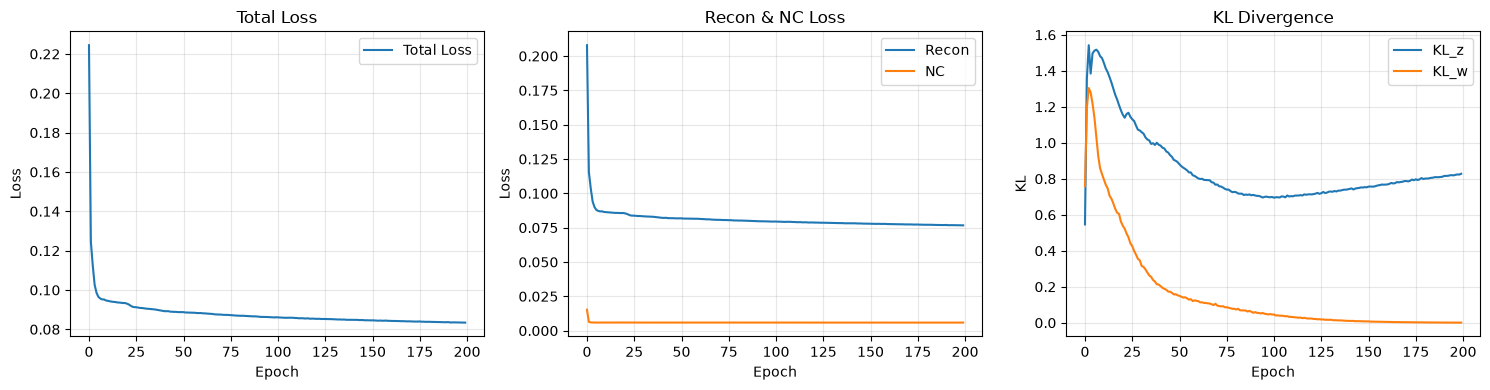

In [13]:
# ========== 4. 训练损失可视化 ==========
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(loss_history["total"], label="Total Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Total Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(loss_history["recon"], label="Recon")
axes[1].plot(loss_history["nc"], label="NC")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].set_title("Recon & NC Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(loss_history["kl_z"], label="KL_z")
axes[2].plot(loss_history["kl_w"], label="KL_w")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("KL"); axes[2].set_title("KL Divergence")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [14]:
# ========== 5. 计算 DEG（在 CPU 上进行） ==========
import importlib
import model as model_module
importlib.reload(model_module)
from model import RUVVAE_DEG, compute_deg

model_cpu = model.cpu()
deg_df, extra = compute_deg(
    model_cpu,
    Y_log,  # log1p 归一化矩阵
    gene_names,
    group_labels,
    groups_unique,
    neg_control_mask,
    batch_labels=batch_labels,
    n_posterior=200,
    n_perm=500
)

print(f"DEG 结果: {deg_df.shape[0]} 个基因")
print(f"\n列名: {list(deg_df.columns)}")

# ---------- 5a. Top 20 DEG（按 GLM delta p-value 排序） ----------
print(f"\nTop 20 DEG (按 GLM delta p_value 排序):")
top_deg = deg_df.sort_values("p_value_glm_delta").head(20)
display(top_deg[["gene", "logFC_bio", "se_glm",
                  "p_value_glm_delta", "p_value_empirical_t",
                  "p_value_perm", "p_value_bayes"]])

# ---------- 5b. 三种 p-value 方法的显著 DEG 数 + FDR 校正 ----------
from scipy.stats import false_discovery_control

p_methods = {
    "GLM delta (Wald)":   "p_value_glm_delta",
    "Welch's t-test":     "p_value_empirical_t",
    "Permutation (500x)": "p_value_perm",
    "Bayesian (后验符号)": "p_value_bayes",
}

print(f"\n=== 不同 p-value 方法下的显著 DEG 数 + FDR 校正 ===")
print(f"{'方法':<24} {'p<0.05':>8} {'p<0.01':>8} {'FDR<0.05':>10} {'FDR<0.01':>10} {'FDR<0.10':>10}")
print("-" * 76)

deg_counts = {}
for name, col in p_methods.items():
    pvals = deg_df[col].values
    if np.any(np.isnan(pvals)):
        # permutation 可能 NaN，跳过 FDR
        valid = ~np.isnan(pvals)
        fdr = np.full_like(pvals, np.nan)
        try:
            fdr_valid = false_discovery_control(pvals[valid])
            fdr[valid] = fdr_valid
        except Exception:
            pass
        n_sig = (pvals < 0.05).sum()
        n_sig01 = (pvals < 0.01).sum()
        n_fdr05 = ((fdr < 0.05) & valid).sum()
        n_fdr01 = ((fdr < 0.01) & valid).sum()
        n_fdr10 = ((fdr < 0.10) & valid).sum()
    else:
        n_sig = (pvals < 0.05).sum()
        n_sig01 = (pvals < 0.01).sum()
        try:
            fdr = false_discovery_control(pvals)
            n_fdr05 = (fdr < 0.05).sum()
            n_fdr01 = (fdr < 0.01).sum()
            n_fdr10 = (fdr < 0.10).sum()
            # 把 FDR 也存到 DataFrame
            deg_df[col.replace("p_value", "fdr")] = fdr
        except Exception:
            n_fdr05 = n_fdr01 = n_fdr10 = -1

    deg_counts[name] = {
        "p<0.05": int(n_sig), "p<0.01": int(n_sig01),
        "FDR<0.05": int(n_fdr05), "FDR<0.01": int(n_fdr01),
        "FDR<0.10": int(n_fdr10),
    }
    print(f"{name:<24} {n_sig:>8} {n_sig01:>8} {n_fdr05:>10} {n_fdr01:>10} {n_fdr10:>10}")

# ---------- 5c. 共识 DEG（在多种方法下同时显著） ----------
print(f"\n=== 多方法共识 DEG（GLM & Welch & Permutation 都 p<0.05）===")
consensus = (deg_df["p_value_glm_delta"] < 0.05) & \
            (deg_df["p_value_empirical_t"] < 0.05) & \
            (deg_df["p_value_perm"] < 0.05)
deg_df["consensus_sig"] = consensus
print(f"共识 DEG (三种都 p<0.05): {consensus.sum()}")
print(f"  其中上调 (logFC > 0): {(consensus & (deg_df['logFC_bio'] > 0)).sum()}")
print(f"  其中下调 (logFC < 0): {(consensus & (deg_df['logFC_bio'] < 0)).sum()}")

# ---------- 5d. 校正后列名汇总 ----------
print(f"\n校正后的 fdr 列已加入 deg_df:")
fdr_cols = [c for c in deg_df.columns if c.startswith("fdr_")]
print(fdr_cols)

DEG 结果: 16428 个基因

列名: ['gene', 'logFC_bio', 'logFC_bio_posterior_mean', 'logFC_bio_posterior_std', 'logFC_bio_ci_low', 'logFC_bio_ci_high', 'logFC_uv_linear', 'logFC_uv_latent', 'logFC_uv_cov', 'logFC_uv_total', 'logFC_uv_posterior_mean', 'logFC_uv_posterior_std', 'se_glm', 't_stat', 'p_value_bayes', 'p_value_empirical_t', 'p_value_glm_delta', 'p_value_perm']

Top 20 DEG (按 GLM delta p_value 排序):


,gene,logFC_bio,se_glm,p_value_glm_delta,p_value_empirical_t,p_value_perm,p_value_bayes
3611,Rnf220,0.312100,0.015367,1.060029e-91,3.864482e-87,0.001996,0.0
7682,Zfp423,0.228285,0.011286,5.668209e-91,1.831731e-85,0.001996,0.0
10932,Tnrc6c,0.204791,0.010129,6.777599e-91,6.974647e-85,0.001996,0.0
1315,Ttll11,0.147755,0.007420,3.171719e-88,3.402011e-79,0.001996,0.0
11035,Dtnb,0.205219,0.010353,1.921788e-87,4.747722e-82,0.001996,0.0
1328,Dennd1a,0.262165,0.013234,2.430349e-87,5.826755e-83,0.001996,0.0
612,Nav1,0.205150,0.010394,1.013368e-86,1.584577e-81,0.001996,0.0
9848,Urgcp,0.116734,0.005916,1.143094e-86,1.835979e-72,0.001996,0.0
8143,Elavl3,0.213497,0.010823,1.277181e-86,1.271436e-81,0.001996,0.0
10965,Rptor,0.170355,0.008657,3.294581e-86,1.783393e-79,0.001996,0.0



=== 不同 p-value 方法下的显著 DEG 数 + FDR 校正 ===
方法                         p<0.05   p<0.01   FDR<0.05   FDR<0.01   FDR<0.10
----------------------------------------------------------------------------
GLM delta (Wald)            14241    13576      14167      13491      14522
Welch's t-test              10075     9305       9808       9112      10193
Permutation (500x)          14284    13615      14200      13518      14545
Bayesian (后验符号)             16146    16033      16146      16033      16190

=== 多方法共识 DEG（GLM & Welch & Permutation 都 p<0.05）===
共识 DEG (三种都 p<0.05): 10072
  其中上调 (logFC > 0): 9939
  其中下调 (logFC < 0): 133

校正后的 fdr 列已加入 deg_df:
['fdr_glm_delta', 'fdr_empirical_t', 'fdr_perm', 'fdr_bayes']


In [15]:
deg_df

,gene,logFC_bio,logFC_bio_posterior_mean,logFC_bio_posterior_std,logFC_bio_ci_low,logFC_bio_ci_high,logFC_uv_linear,logFC_uv_latent,logFC_uv_cov,logFC_uv_total,...,t_stat,p_value_bayes,p_value_empirical_t,p_value_glm_delta,p_value_perm,fdr_glm_delta,fdr_empirical_t,fdr_perm,fdr_bayes,consensus_sig
0,Xkr4,0.299897,0.321935,0.001069,0.319925,0.324059,-0.016317,0.000059,-0.020148,-0.020089,...,17.046011,0.0,6.028284e-63,3.742171e-65,0.001996,1.249520e-63,2.904183e-61,0.002547,0.0,True
1,Gm1992,0.030817,0.215304,0.000799,0.213768,0.216733,-0.151641,0.000066,-0.184514,-0.184448,...,4.838691,0.0,1.488265e-06,1.306969e-06,0.001996,1.954742e-06,3.400243e-06,0.002547,0.0,True
2,Gm19938,0.117598,0.183395,0.000568,0.182298,0.184449,-0.019949,-0.000039,-0.065092,-0.065131,...,15.323784,0.0,6.705070e-50,5.303793e-53,0.001996,5.567457e-52,8.999255e-49,0.002547,0.0,True
3,Rp1,0.003464,0.009665,0.000118,0.009454,0.009905,0.008243,0.000013,-0.006160,-0.006147,...,7.059561,0.0,7.907455e-01,1.670297e-12,0.001996,3.183253e-12,9.428340e-01,0.002547,0.0,False
4,Mrpl15,0.023439,0.030697,0.000297,0.030088,0.031212,0.004613,0.000056,-0.007291,-0.007235,...,11.161245,0.0,7.096931e-10,6.310139e-29,0.001996,2.107827e-28,1.885628e-09,0.002547,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16423,Vamp7,0.014004,0.006301,0.000233,0.005884,0.006754,0.001842,0.000052,0.008246,0.008299,...,8.391320,0.0,3.760363e-05,4.807130e-17,0.001996,1.071381e-16,7.972027e-05,0.002547,0.0,True
16424,Spry3,-0.001412,-0.004208,0.000101,-0.004411,-0.004023,-0.000269,-0.000023,0.002617,0.002594,...,-3.037067,0.0,8.563377e-01,2.388924e-03,0.005988,3.013765e-03,9.865299e-01,0.007341,0.0,False
16425,Tmlhe,0.053601,0.075330,0.000350,0.074672,0.076033,-0.011531,-0.000079,-0.021791,-0.021870,...,14.095253,0.0,1.111681e-31,4.061896e-45,0.001996,2.686346e-44,6.306180e-31,0.002547,0.0,True
16426,4933409K07Rik,0.004118,0.004058,0.000158,0.003745,0.004349,-0.013368,0.000004,0.000130,0.000134,...,5.380577,0.0,3.825571e-01,7.424763e-08,0.001996,1.171250e-07,5.275011e-01,0.002547,0.0,False


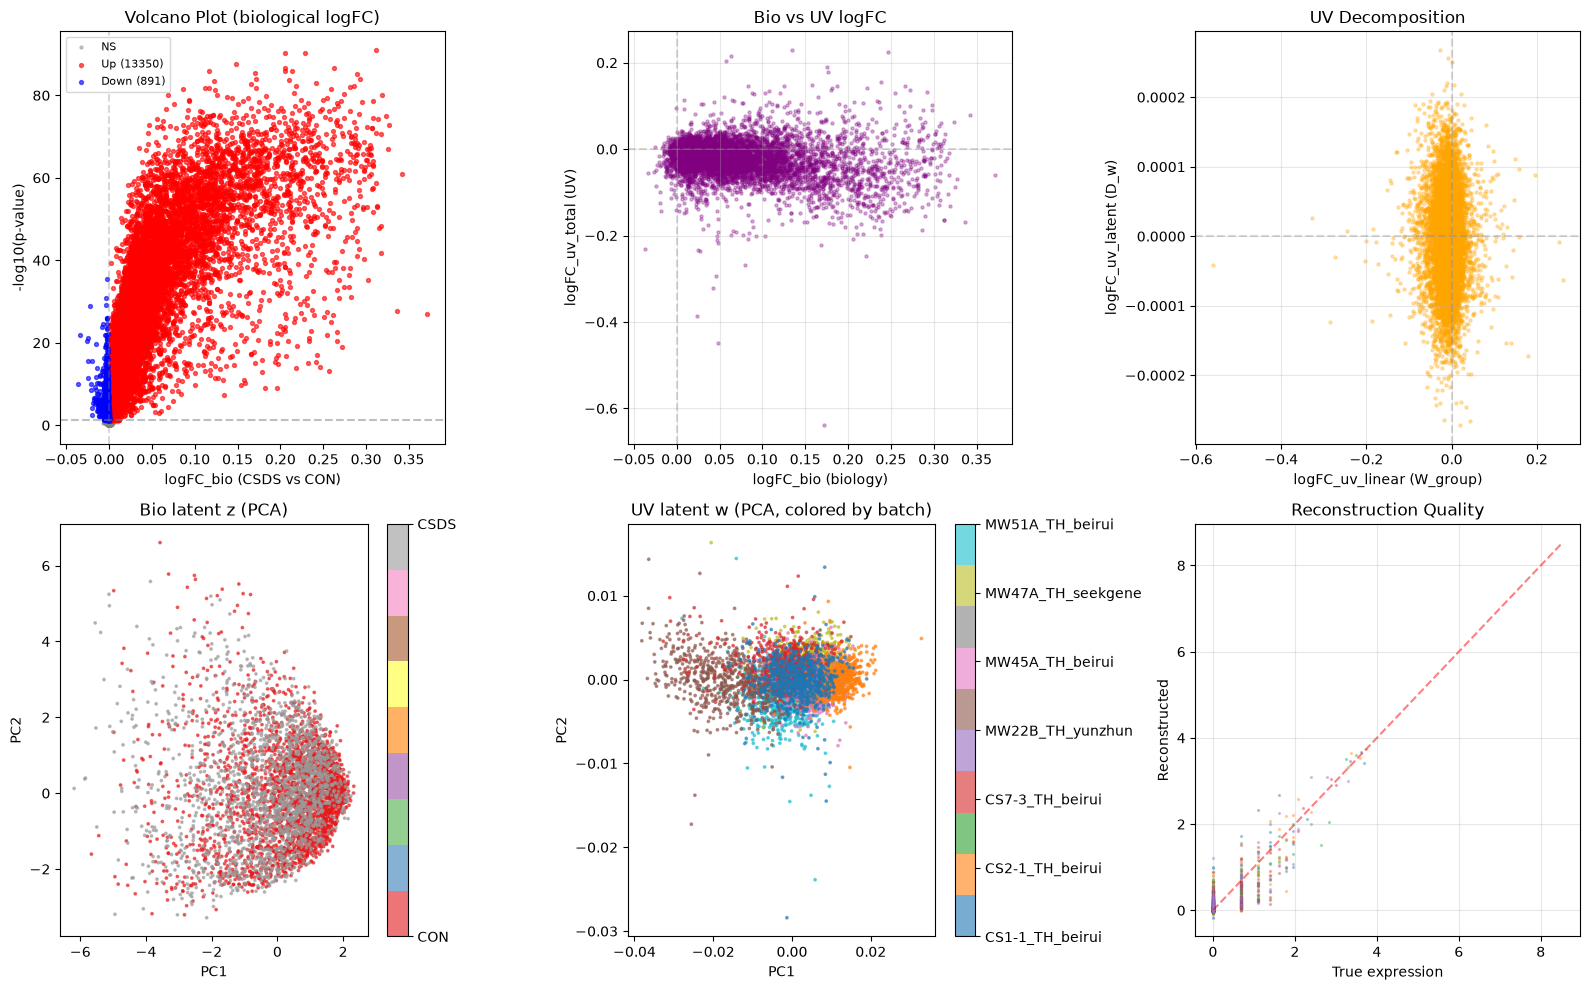

In [16]:
# ========== 6. 结果可视化 ==========
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 6a. Volcano plot (使用 logFC_bio_posterior_mean)
ax = axes[0, 0]
logFC = deg_df["logFC_bio"].values
pval = deg_df["p_value_glm_delta"].values
neg_log_p = -np.log10(pval + 1e-300)

sig_up = (pval < 0.05) & (logFC > 0)
sig_down = (pval < 0.05) & (logFC < 0)
ax.scatter(logFC[~sig_up & ~sig_down], neg_log_p[~sig_up & ~sig_down], 
           c="gray", alpha=0.4, s=5, label="NS")
ax.scatter(logFC[sig_up], neg_log_p[sig_up], 
           c="red", alpha=0.6, s=8, label=f"Up ({(sig_up).sum()})")
ax.scatter(logFC[sig_down], neg_log_p[sig_down], 
           c="blue", alpha=0.6, s=8, label=f"Down ({(sig_down).sum()})")
ax.axhline(-np.log10(0.05), c="gray", ls="--", alpha=0.5)
ax.axvline(0, c="gray", ls="--", alpha=0.3)
ax.set_xlabel("logFC_bio (CSDS vs CON)"); ax.set_ylabel("-log10(p-value)")
ax.set_title("Volcano Plot (biological logFC)"); ax.legend(fontsize=8)

# 6b. UV vs Bio logFC 比较
ax = axes[0, 1]
ax.scatter(deg_df["logFC_bio"], deg_df["logFC_uv_total"], 
           alpha=0.3, s=5, c="purple")
ax.set_xlabel("logFC_bio (biology)"); ax.set_ylabel("logFC_uv_total (UV)")
ax.set_title("Bio vs UV logFC"); ax.grid(True, alpha=0.3)
ax.axhline(0, c="gray", ls="--", alpha=0.3)
ax.axvline(0, c="gray", ls="--", alpha=0.3)

# 6c. UV 分解: UV_linear vs UV_latent
ax = axes[0, 2]
ax.scatter(deg_df["logFC_uv_linear"], deg_df["logFC_uv_latent"], 
           alpha=0.3, s=5, c="orange")
ax.set_xlabel("logFC_uv_linear (W_group)"); ax.set_ylabel("logFC_uv_latent (D_w)")
ax.set_title("UV Decomposition"); ax.grid(True, alpha=0.3)
ax.axhline(0, c="gray", ls="--", alpha=0.3)
ax.axvline(0, c="gray", ls="--", alpha=0.3)

# 6d. 生物学潜变量 z 的 PCA
ax = axes[1, 0]
z_mu = extra["z_mu"]
z_mu = np.nan_to_num(z_mu, nan=0.0)
from sklearn.decomposition import PCA
z_pca = PCA(n_components=2).fit_transform(z_mu)
scatter = ax.scatter(z_pca[:, 0], z_pca[:, 1], c=[groups_unique.index(g) for g in group_labels], 
                     cmap="Set1", s=3, alpha=0.6)
ax.set_title("Bio latent z (PCA)"); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
cbar = plt.colorbar(scatter, ax=ax, ticks=[0, 1])
cbar.set_ticklabels(groups_unique)

# 6e. UV 潜变量 w 的 PCA
ax = axes[1, 1]
w_mu = extra["w_mu"]
w_mu = np.nan_to_num(w_mu, nan=0.0)
w_pca = PCA(n_components=2).fit_transform(w_mu)
scatter = ax.scatter(w_pca[:, 0], w_pca[:, 1], c=[batches_unique.index(b) for b in batch_labels],
                     cmap="tab10", s=3, alpha=0.6)
ax.set_title("UV latent w (PCA, colored by batch)"); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
cbar = plt.colorbar(scatter, ax=ax, ticks=range(len(batches_unique)))
cbar.set_ticklabels(batches_unique)

# 6f. 重建质量
ax = axes[1, 2]
model_cpu.eval()
with torch.no_grad():
    c_dict_cpu = {}
    group_idx = np.array([groups_unique.index(g) for g in group_labels])
    c_dict_cpu["group"] = torch.FloatTensor(np.eye(len(groups_unique))[group_idx])
    batch_idx = np.array([batches_unique.index(b) for b in batch_labels])
    c_dict_cpu["batch"] = torch.FloatTensor(np.eye(len(batches_unique))[batch_idx])
    out = model_cpu(torch.FloatTensor(Y_log), c_dict_cpu, torch.BoolTensor(neg_control_mask))
    y_recon = out["y_recon"].numpy()

# 随机选 200 个细胞画散点图
n_sample = min(200, Y_log.shape[0])
idx_plot = np.random.choice(Y_log.shape[0], n_sample, replace=False)
for i in idx_plot[:5]:
    ax.scatter(Y_log[i, :200], y_recon[i, :200], s=2, alpha=0.3)
ax.plot([0, Y_log.max()], [0, Y_log.max()], "r--", alpha=0.5)
ax.set_xlabel("True expression"); ax.set_ylabel("Reconstructed")
ax.set_title("Reconstruction Quality"); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
def compute_metrics(y_t, y_p):
    """向量化 R² + Pearson r（按基因 / 按样本 / 整体），无 for 循环"""
    # 整体 R²
    r2_total = float(r2_score(y_t.ravel(), y_p.ravel()))

    # 向量化按基因 Pearson r
    yt = y_t - y_t.mean(axis=0, keepdims=True)
    yp = y_p - y_p.mean(axis=0, keepdims=True)
    pearson_per_gene = (yt * yp).sum(axis=0) / \
        (np.sqrt((yt ** 2).sum(axis=0) * (yp ** 2).sum(axis=0)) + 1e-12)

    # 向量化按样本 Pearson r
    yt_c = y_t - y_t.mean(axis=1, keepdims=True)
    yp_c = y_p - y_p.mean(axis=1, keepdims=True)
    pearson_per_cell = (yt_c * yp_c).sum(axis=1) / \
        (np.sqrt((yt_c ** 2).sum(axis=1) * (yp_c ** 2).sum(axis=1)) + 1e-12)

    # 向量化按基因 R²
    ss_res_g = ((y_t - y_p) ** 2).sum(axis=0)
    ss_tot_g = ((y_t - y_t.mean(axis=0, keepdims=True)) ** 2).sum(axis=0) + 1e-12
    r2_per_gene = 1.0 - ss_res_g / ss_tot_g

    # 向量化按样本 R²
    ss_res_c = ((y_t - y_p) ** 2).sum(axis=1)
    ss_tot_c = ((y_t - y_t.mean(axis=1, keepdims=True)) ** 2).sum(axis=1) + 1e-12
    r2_per_cell = 1.0 - ss_res_c / ss_tot_c

    return {
        "r2_total": r2_total,
        "r2_per_gene_mean": float(np.mean(r2_per_gene)),
        "r2_per_gene_median": float(np.median(r2_per_gene)),
        "r2_per_cell_mean": float(np.mean(r2_per_cell)),
        "r2_per_cell_median": float(np.median(r2_per_cell)),
        "pearson_per_gene_mean": float(np.mean(pearson_per_gene)),
        "pearson_per_gene_median": float(np.median(pearson_per_gene)),
        "pearson_per_cell_mean": float(np.mean(pearson_per_cell)),
        "pearson_per_cell_median": float(np.median(pearson_per_cell)),
    }

=== 重建质量评估 ===

【整体重构 y_recon = y_bio - delta_lat - delta_cov】
  r2_total                    : 0.6795
  r2_per_gene_mean            : -55973264.0000
  r2_per_gene_median          : 0.0844
  r2_per_cell_mean            : 0.6363
  r2_per_cell_median          : 0.6408
  pearson_per_gene_mean       : 0.3310
  pearson_per_gene_median     : 0.2949
  pearson_per_cell_mean       : 0.7963
  pearson_per_cell_median     : 0.8007

【生物学通道 y_bio (VAE 直接输出)】
  r2_total                    : 0.3204
  r2_per_gene_mean            : -51965916.0000
  r2_per_gene_median          : -0.0250
  r2_per_cell_mean            : 0.1826
  r2_per_cell_median          : 0.2442
  pearson_per_gene_mean       : 0.3197
  pearson_per_gene_median     : 0.2831
  pearson_per_cell_mean       : 0.5563
  pearson_per_cell_median     : 0.7005


/tmp/ipykernel_1101759/770492109.py:110: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEOGRAPH-6309}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1101759/770492109.py:110: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1101759/770492109.py:110: UserWarning: Glyph 22240 (\N{CJK UNIFIED IDEOGRAPH-56E0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1101759/770492109.py:110: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1101759/770492109.py:110: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1101759/770492109.py:110: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1101759/770492109.py:110: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOG

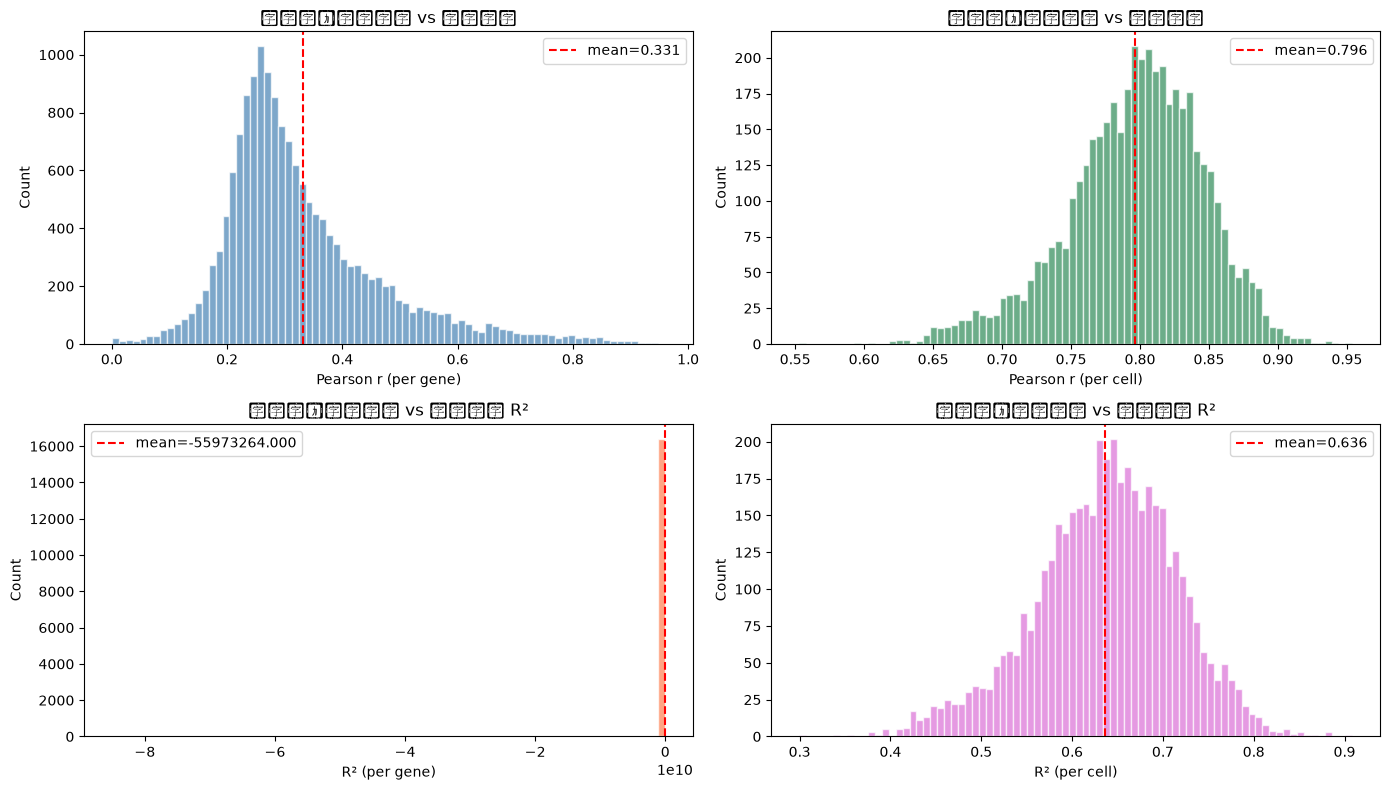


=== 重建质量总结 ===
指标                                      y_recon (含 UV)         y_bio (干净)
---------------------------------------------------------------------------
r2_total                                        0.6795             0.3204
r2_per_gene_mean                        -55973264.0000     -51965916.0000
r2_per_gene_median                              0.0844            -0.0250
r2_per_cell_mean                                0.6363             0.1826
r2_per_cell_median                              0.6408             0.2442
pearson_per_gene_mean                           0.3310             0.3197
pearson_per_gene_median                         0.2949             0.2831
pearson_per_cell_mean                           0.7963             0.5563
pearson_per_cell_median                         0.8007             0.7005


In [26]:
# ========== 7. Reconstruction Quality Evaluation: R² + Pearson r ==========
from sklearn.metrics import r2_score
import torch
import numpy as np
import matplotlib.pyplot as plt

model_cpu.eval()
with torch.no_grad():
    c_dict_eval = {}
    group_idx = np.array([groups_unique.index(g) for g in group_labels])
    c_dict_eval["group"] = torch.FloatTensor(np.eye(len(groups_unique))[group_idx])
    batch_idx = np.array([batches_unique.index(b) for b in batch_labels])
    c_dict_eval["batch"] = torch.FloatTensor(np.eye(len(batches_unique))[batch_idx])
    out_eval = model_cpu(torch.FloatTensor(Y_log), c_dict_eval, torch.BoolTensor(neg_control_mask))
    y_recon_eval = out_eval["y_recon"].numpy()
    y_bio_eval = out_eval["y_bio"].numpy()

y_true = Y_log


def compute_metrics(y_t, y_p):
    """Vectorized R² + Pearson r (per gene / per cell / overall), without for loops"""
    r2_total = float(r2_score(y_t.ravel(), y_p.ravel()))
    yt = y_t - y_t.mean(axis=0, keepdims=True)
    yp = y_p - y_p.mean(axis=0, keepdims=True)
    pearson_per_gene = (yt * yp).sum(axis=0) / \
        (np.sqrt((yt ** 2).sum(axis=0) * (yp ** 2).sum(axis=0)) + 1e-12)
    yt_c = y_t - y_t.mean(axis=1, keepdims=True)
    yp_c = y_p - y_p.mean(axis=1, keepdims=True)
    pearson_per_cell = (yt_c * yp_c).sum(axis=1) / \
        (np.sqrt((yt_c ** 2).sum(axis=1) * (yp_c ** 2).sum(axis=1)) + 1e-12)
    ss_res_g = ((y_t - y_p) ** 2).sum(axis=0)
    ss_tot_g = ((y_t - y_t.mean(axis=0, keepdims=True)) ** 2).sum(axis=0) + 1e-12
    r2_per_gene = 1.0 - ss_res_g / ss_tot_g
    ss_res_c = ((y_t - y_p) ** 2).sum(axis=1)
    ss_tot_c = ((y_t - y_t.mean(axis=1, keepdims=True)) ** 2).sum(axis=1) + 1e-12
    r2_per_cell = 1.0 - ss_res_c / ss_tot_c
    return {
        "r2_total": r2_total,
        "r2_per_gene_mean": float(np.mean(r2_per_gene)),
        "r2_per_gene_median": float(np.median(r2_per_gene)),
        "r2_per_cell_mean": float(np.mean(r2_per_cell)),
        "r2_per_cell_median": float(np.median(r2_per_cell)),
        "pearson_per_gene_mean": float(np.mean(pearson_per_gene)),
        "pearson_per_gene_median": float(np.median(pearson_per_gene)),
        "pearson_per_cell_mean": float(np.mean(pearson_per_cell)),
        "pearson_per_cell_median": float(np.median(pearson_per_cell)),
    }


print("=== Reconstruction Quality Evaluation ===\n")
metrics_recon = compute_metrics(y_true, y_recon_eval)
metrics_clean = compute_metrics(y_true, y_bio_eval)

print("[Overall Reconstruction y_recon = y_bio - delta_lat - delta_cov]")
for k, v in metrics_recon.items():
    print(f"  {k:<28}: {v:.4f}")

print("\n[Biological Channel y_bio (Direct VAE output)]")
for k, v in metrics_clean.items():
    print(f"  {k:<28}: {v:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

yt_ = y_true - y_true.mean(axis=0, keepdims=True)
yr_ = y_recon_eval - y_recon_eval.mean(axis=0, keepdims=True)
pearson_per_gene_arr = (yt_ * yr_).sum(axis=0) / (
    np.sqrt((yt_ ** 2).sum(axis=0) * (yr_ ** 2).sum(axis=0)) + 1e-12
)
axes[0, 0].hist(pearson_per_gene_arr, bins=80, color="steelblue", alpha=0.7, edgecolor="white")
axes[0, 0].axvline(np.mean(pearson_per_gene_arr), color="red", ls="--",
                    label=f"mean={np.mean(pearson_per_gene_arr):.3f}")
axes[0, 0].set_xlabel("Pearson r (per gene)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Per Gene: True vs Reconstructed Expression")
axes[0, 0].legend()

yt_c = y_true - y_true.mean(axis=1, keepdims=True)
yr_c = y_recon_eval - y_recon_eval.mean(axis=1, keepdims=True)
pearson_per_cell_arr = (yt_c * yr_c).sum(axis=1) / (
    np.sqrt((yt_c ** 2).sum(axis=1) * (yr_c ** 2).sum(axis=1)) + 1e-12
)
axes[0, 1].hist(pearson_per_cell_arr, bins=80, color="seagreen", alpha=0.7, edgecolor="white")
axes[0, 1].axvline(np.mean(pearson_per_cell_arr), color="red", ls="--",
                    label=f"mean={np.mean(pearson_per_cell_arr):.3f}")
axes[0, 1].set_xlabel("Pearson r (per cell)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Per Cell: True vs Reconstructed Expression")
axes[0, 1].legend()

ss_res_g = ((y_true - y_recon_eval) ** 2).sum(axis=0)
ss_tot_g = ((y_true - y_true.mean(axis=0, keepdims=True)) ** 2).sum(axis=0) + 1e-12
r2_per_gene_arr = 1.0 - ss_res_g / ss_tot_g
axes[1, 0].hist(r2_per_gene_arr, bins=80, color="coral", alpha=0.7, edgecolor="white")
axes[1, 0].axvline(np.mean(r2_per_gene_arr), color="red", ls="--",
                    label=f"mean={np.mean(r2_per_gene_arr):.3f}")
axes[1, 0].set_xlabel("R² (per gene)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Per Gene: True vs Reconstructed Expression R²")
axes[1, 0].legend()

ss_res_c = ((y_true - y_recon_eval) ** 2).sum(axis=1)
ss_tot_c = ((y_true - y_true.mean(axis=1, keepdims=True)) ** 2).sum(axis=1) + 1e-12
r2_per_cell_arr = 1.0 - ss_res_c / ss_tot_c
axes[1, 1].hist(r2_per_cell_arr, bins=80, color="orchid", alpha=0.7, edgecolor="white")
axes[1, 1].axvline(np.mean(r2_per_cell_arr), color="red", ls="--",
                    label=f"mean={np.mean(r2_per_cell_arr):.3f}")
axes[1, 1].set_xlabel("R² (per cell)")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Per Cell: True vs Reconstructed Expression R²")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\n=== Reconstruction Quality Summary ===")
print(f"{'Metric':<35} {'y_recon (w/ UV)':>18} {'y_bio (Clean)':>18}")
print("-" * 75)
for k in metrics_recon:
    print(f"{k:<35} {metrics_recon[k]:>18.4f} {metrics_clean[k]:>18.4f}")